# Notebook 00 — Generación de Datos Sintéticos con Modelo de Variable Latente

## Motivación


Este notebook genera un dataset sintético usando un
**modelo de variable latente**: cada vehículo tiene un estado de salud
(`health_score`) del que se derivan *tanto* las lecturas de sensores *como* el
target, con ruido explícito en cada relación. Esto produce correlaciones reales
pero imperfectas entre sensores y necesidad de mantenimiento.

## Arquitectura del modelo generativo

```
health_score ~ Beta(2, 3)
      │
      ├──► Usage_Hours, Tire_Pressure, Fuel_Consumption   (correlación fuerte)
      ├──► Battery_Status, Vibration_Levels               (correlación fuerte)
      ├──► Delivery_Times                                  (correlación débil)
      ├──► Oil_Quality, Brake_Condition                    (categóricas correlacionadas)
      ├──► Failure_History, Anomalies_Detected             (binarias vía logística + ruido)
      └──► Maintenance_Required                            (target vía logística + ruido)
```

## Propiedades esperadas del dataset

| Propiedad | Valor |
|---|---|
| Filas | 92,000 |
| Balance de clases | ~75% Requiere / ~25% No requiere |

In [1]:
%pip install -r ../requirements.txt -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires einops<1,>=0.7, which is not installed.
autogluon-timeseries 1.5.0 requires peft<0.18,>=0.13.0, which is not installed.
dash 2.18.1 requires dash-core-components==2.0.0, which is not installed.
dash 2.18.1 requires dash-html-components==2.0.0, which is not installed.
dash 2.18.1 requires dash-table==5.0.0, which is not installed.
skops 0.14.0 requires prettytable>=3.9, which is not installed.
aiobotocore 3.6.0 requires botocore<1.43.1,>=1.42.90, but you have botocore 1.34.162 which is incompatible.
amazon-sagemaker-sql-editor 0.2.4 requires boto3<2.0,>=1.42.2, but you have boto3 1.34.69 which is inco

Note: you may need to restart the kernel to use updated packages.


---
## 1. Configuración

In [2]:
import logging
import warnings
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from scipy.special import expit    # función logística numéricamente estable

warnings.filterwarnings("ignore")

logging.basicConfig(
    level   = logging.INFO,
    format  = "%(asctime)s | %(levelname)s | %(message)s",
    datefmt = "%Y-%m-%d %H:%M:%S",
    force   = True,
)
log = logging.getLogger("notebook_00")

with open("../config.yaml") as f:
    CFG = yaml.safe_load(f)

N    = 5_000
SEED = CFG["modeling"]["random_seed"]
rng  = np.random.default_rng(SEED)

OUTPUT_PATH = Path("../") / CFG["etl"]["raw_files"]["logistics"]
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

log.info("N = %d | seed = %d | output: %s", N, SEED, OUTPUT_PATH)

2026-05-22 16:47:30 | INFO | N = 5000 | seed = 123 | output: ../data/raw/logistics_dataset_with_maintenance_required.csv


---
## 2. Variable latente: health_score

`health_score ~ Beta(2, 3)` representa el estado de salud del vehículo:
- Valor cercano a **1** → vehículo en buen estado
- Valor cercano a **0** → vehículo deteriorado

Beta(2, 3) tiene media 0.4 y sesga la distribución hacia valores bajos,
replicando que la mayoría de la flota necesita mantenimiento (~75%).

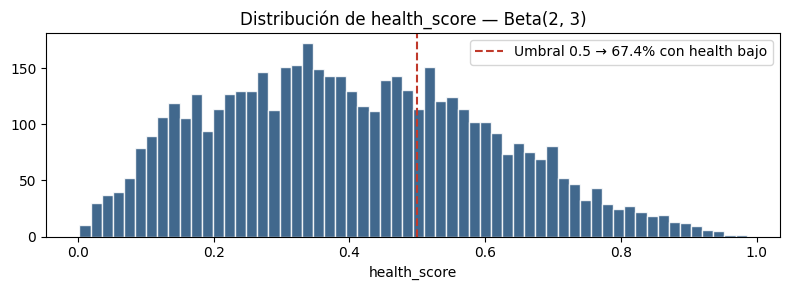

2026-05-22 16:47:35 | INFO | health_score — media: 0.402 | < 0.5: 67.4%


In [3]:
health = rng.beta(2, 3, N)

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(health, bins=60, color="#1F4E79", edgecolor="white", alpha=0.85)
ax.axvline(0.5, color="#C0392B", linestyle="--", linewidth=1.5,
           label=f"Umbral 0.5 → {(health < 0.5).mean()*100:.1f}% con health bajo")
ax.set_title("Distribución de health_score — Beta(2, 3)", fontsize=12)
ax.set_xlabel("health_score")
ax.legend()
plt.tight_layout()
plt.show()

log.info("health_score — media: %.3f | < 0.5: %.1f%%",
         health.mean(), (health < 0.5).mean() * 100)

---
## 3. Target y features binarias

`Maintenance_Required`, `Failure_History` y `Anomalies_Detected` se generan
mediante una **función logística con ruido gaussiano** sobre `health_score`.
Esto produce correlaciones fuertes pero no determinísticas:

$$P(\text{required}=1 \mid h) = \sigma(-3.5 + 8(1-h) + \epsilon), \quad \epsilon \sim \mathcal{N}(0, 0.6)$$

In [4]:
# --- Maintenance_Required ---
maint_logit          = -3.5 + 8.0 * (1 - health) + rng.normal(0, 0.6, N)
maint_prob           = expit(maint_logit)
maintenance_required = rng.binomial(1, np.clip(maint_prob, 0.02, 0.98), N)

# --- Failure_History: correlacionado con health, más ruido que el target ---
fail_logit      = -3.0 + 7.0 * (1 - health) + rng.normal(0, 1.2, N)
failure_history = rng.binomial(1, np.clip(expit(fail_logit), 0.02, 0.98), N)

# --- Anomalies_Detected: correlacionado con health, semi-independiente de Failure ---
anom_logit         = -2.5 + 6.5 * (1 - health) + rng.normal(0, 1.4, N)
anomalies_detected = rng.binomial(1, np.clip(expit(anom_logit), 0.02, 0.98), N)

log.info("Maintenance_Required — 1: %.1f%% | 0: %.1f%%",
         maintenance_required.mean() * 100, (1 - maintenance_required.mean()) * 100)
log.info("Failure_History      — 1: %.1f%%", failure_history.mean() * 100)
log.info("Anomalies_Detected   — 1: %.1f%%", anomalies_detected.mean() * 100)

2026-05-22 16:47:40 | INFO | Maintenance_Required — 1: 69.6% | 0: 30.4%


2026-05-22 16:47:40 | INFO | Failure_History      — 1: 69.0%


2026-05-22 16:47:40 | INFO | Anomalies_Detected   — 1: 69.9%


---
## 4. Features numéricas condicionadas a health_score

Cada sensor sigue una distribución normal cuya media depende linealmente
de `health_score`, con desviación estándar calibrada para producir
correlaciones Pearson de 0.25–0.55 con el target.

In [5]:
VAL = CFG["etl"]["validation"]

# Usage_Hours: mayor uso acumulado → peor salud
usage_hours = rng.normal(15_000 * (1 - health) + 5_000, 4_000, N)
usage_hours = usage_hours.clip(VAL["usage_hours_min"], VAL["usage_hours_max"]).round(0)

# Tire_Pressure: disminuye con el deterioro [psi]
tire_pressure = rng.normal(25 + 30 * health, 5, N)
tire_pressure = tire_pressure.clip(VAL["tire_pressure_min"], VAL["tire_pressure_max"]).round(1)

# Fuel_Consumption: aumenta con el deterioro [L/100km]
fuel_consumption = rng.normal(8 + 10 * (1 - health), 1.5, N).clip(3, 25).round(2)

# Battery_Status: escala 0–1, disminuye con el deterioro
battery_status = rng.normal(0.25 + 0.6 * health, 0.12, N).clip(0.01, 1.0).round(3)

# Vibration_Levels: aumenta con el deterioro
vibration_levels = rng.normal(1.0 + 7.0 * (1 - health), 1.0, N).clip(0.1, 10.0).round(2)

# Delivery_Times: correlación débil [horas]
delivery_times = rng.normal(6 + 4 * (1 - health), 1.5, N).clip(1, 20).round(1)

# Load_Capacity: independiente del estado [kg]
load_capacity = rng.choice([5_000, 8_000, 10_000, 15_000, 20_000], N).astype(float)

# Actual_Load: leve sobrecarga en vehículos deteriorados
load_ratio_raw = rng.normal(0.65 + 0.15 * (1 - health), 0.12, N).clip(0.1, 1.2)
actual_load    = (load_ratio_raw * load_capacity).round(0)

log.info("Features numéricas generadas OK")

2026-05-22 16:47:48 | INFO | Features numéricas generadas OK


---
## 5. Features categóricas

`Oil_Quality` y `Brake_Condition` están correlacionadas con `health_score`
mediante probabilidades dependientes del estado del vehículo.
El resto se muestrea de forma independiente.

In [6]:
def sample_cat_vectorized(categories: list, prob_matrix: np.ndarray) -> np.ndarray:
    """
    Muestrea categorías con probabilidades distintas por fila (vectorizado).

    Args:
        categories  : lista de strings de longitud K
        prob_matrix : array (N, K) con probabilidades por fila (suman 1)

    Returns:
        array (N,) de strings
    """
    cumprobs = prob_matrix.cumsum(axis=1)
    u        = rng.uniform(0, 1, N)
    indices  = (u[:, None] >= cumprobs).sum(axis=1)
    indices  = np.clip(indices, 0, len(categories) - 1)
    return np.array(categories)[indices]


# Vehicle_Type: independiente
vehicle_type = rng.choice(["Truck", "Van", "SUV", "Bus"], N,
                           p=[0.40, 0.30, 0.20, 0.10])

# Route_Info: independiente
route_info = rng.choice(["Urban", "Highway", "Rural"], N,
                         p=[0.35, 0.45, 0.20])

# Weather_Conditions: independiente
weather_conditions = rng.choice(
    ["Clear", "Rainy", "Foggy", "Windy", "Stormy"], N,
    p=[0.45, 0.25, 0.10, 0.15, 0.05],
)

# Road_Conditions: independiente
road_conditions = rng.choice(
    ["Good", "Fair", "Poor", "Under Construction"], N,
    p=[0.40, 0.35, 0.15, 0.10],
)

# Oil_Quality: correlacionada con health [Good, Fair, Poor]
good_oil = np.clip(0.10 + 0.70 * health, 0.02, 0.97)
poor_oil = np.clip(0.60 - 0.70 * health, 0.02, 0.97)
fair_oil = np.clip(1 - good_oil - poor_oil, 0.02, 0.97)
total    = good_oil + fair_oil + poor_oil
oil_mat  = np.column_stack([good_oil / total, fair_oil / total, poor_oil / total])
oil_quality = sample_cat_vectorized(["Good", "Fair", "Poor"], oil_mat)

# Brake_Condition: correlacionada con health [Good, Fair, Worn]
good_brk = np.clip(0.10 + 0.60 * health, 0.02, 0.97)
worn_brk = np.clip(0.55 - 0.60 * health, 0.02, 0.97)
fair_brk = np.clip(1 - good_brk - worn_brk, 0.02, 0.97)
total    = good_brk + fair_brk + worn_brk
brk_mat  = np.column_stack([good_brk / total, fair_brk / total, worn_brk / total])
brake_condition = sample_cat_vectorized(["Good", "Fair", "Worn"], brk_mat)

# Maintenance_Type: correlacionada con el target
maintenance_type = np.where(
    maintenance_required == 1,
    rng.choice(["Corrective", "Preventive"], N, p=[0.65, 0.35]),
    rng.choice(["Preventive", "Inspection"], N, p=[0.70, 0.30]),
)

log.info("Features categóricas generadas OK")

2026-05-22 16:48:04 | INFO | Features categóricas generadas OK


---
## 6. Identidad y fechas

In [7]:
# Vehicle_ID: entero secuencial (1 a N)
vehicle_id = np.arange(1, N + 1)

# Centros de distribución — porcentajes del archivo taller.xlsx
CENTERS = {
    1: ('Cuautitlán',        19.6977, -99.2008, 0.30),
    2: ('Santa Bárbara',     19.7218, -99.1912, 0.20),
    3: ('San Martín Obispo', 19.5996, -99.2096, 0.15),
    4: ('Chalco',            19.2475, -98.8826, 0.12),
    5: ('Tultepec',          19.6685, -99.1213, 0.10),
    6: ('Tepotzotlán',       19.7363, -99.2196, 0.13),
}
center_probs = [c[3] for c in CENTERS.values()]
center_id    = rng.choice(list(CENTERS.keys()), N, p=center_probs)


# Make_and_Model: independiente
make_and_model = rng.choice(
    ["Ford F-150", "Chevy Silverado", "Tesla Semi",
     "Volvo FH", "Mercedes Sprinter", "Toyota Hilux",
     "Isuzu NPR", "Freightliner Cascadia"],
    N,
)

# Year_of_Manufacture: independiente
year_of_manufacture = rng.integers(2005, 2024, N)

# Last_Maintenance_Date: vehículos deteriorados → más días sin mantenimiento
today      = datetime.today().date()
days_since = rng.normal(60 + 350 * (1 - health), 60, N).clip(1, 730).round(0).astype(int)
last_maintenance_date = [
    (today - timedelta(days=int(d))).strftime("%Y-%m-%d")
    for d in days_since
]

log.info("Identidad y fechas generadas OK")

2026-05-22 16:48:06 | INFO | Identidad y fechas generadas OK


---
## 7. Ensamble del DataFrame

In [8]:
df = pd.DataFrame({
    "Vehicle_ID":            vehicle_id,
    "Make_and_Model":        make_and_model,
    "Year_of_Manufacture":   year_of_manufacture,
    "Vehicle_Type":          vehicle_type,
    "Usage_Hours":           usage_hours,
    "Route_Info":            route_info,
    "Load_Capacity":         load_capacity,
    "Actual_Load":           actual_load,
    "Last_Maintenance_Date": last_maintenance_date,
    "Maintenance_Type":      maintenance_type,
    "Tire_Pressure":         tire_pressure,
    "Fuel_Consumption":      fuel_consumption,
    "Battery_Status":        battery_status,
    "Vibration_Levels":      vibration_levels,
    "Oil_Quality":           oil_quality,
    "Brake_Condition":       brake_condition,
    "Failure_History":       failure_history,
    "Anomalies_Detected":    anomalies_detected,
    "Maintenance_Required":  maintenance_required,
    "Weather_Conditions":    weather_conditions,
    "Road_Conditions":       road_conditions,
    "Delivery_Times":        delivery_times,
    "center_id":             center_id,
})

log.info("DataFrame ensamblado: %d filas x %d columnas", *df.shape)

# Verificar que las columnas coinciden exactamente con config.yaml
expected = set(CFG["etl"]["expected_columns"]["logistics"])
actual   = set(df.columns)
missing  = expected - actual
extra    = actual - expected
assert not missing, f"Columnas faltantes: {missing}"
assert not extra,   f"Columnas extra (no esperadas): {extra}"
log.info("✓ Columnas validadas contra config.yaml — %d columnas OK", len(df.columns))

2026-05-22 16:48:08 | INFO | DataFrame ensamblado: 5000 filas x 23 columnas


2026-05-22 16:48:08 | INFO | ✓ Columnas validadas contra config.yaml — 23 columnas OK


---
## 8. Verificación estadística

In [9]:
# Balance de clases
counts = df["Maintenance_Required"].value_counts()
log.info("Balance — 0 (No requiere): %d (%.1f%%) | 1 (Requiere): %d (%.1f%%)",
         counts[0], counts[0]/N*100, counts[1], counts[1]/N*100)

# Correlaciones con el target
raw_num_feats = [f for f in CFG["modeling"]["features"]["numeric"]
                 if f not in ("days_since_maintenance", "load_ratio")]

corr = (df[raw_num_feats + ["Maintenance_Required"]]
        .corr()["Maintenance_Required"]
        .drop("Maintenance_Required")
        .sort_values(key=abs, ascending=False))

print("\nCorrelación Pearson con Maintenance_Required:")
print(corr.round(3).to_string())

2026-05-22 16:48:19 | INFO | Balance — 0 (No requiere): 1519 (30.4%) | 1 (Requiere): 3481 (69.6%)



Correlación Pearson con Maintenance_Required:
Vibration_Levels      0.434
Fuel_Consumption      0.432
Tire_Pressure        -0.404
Battery_Status       -0.386
Usage_Hours           0.321
Failure_History       0.247
Delivery_Times        0.243
Anomalies_Detected    0.213


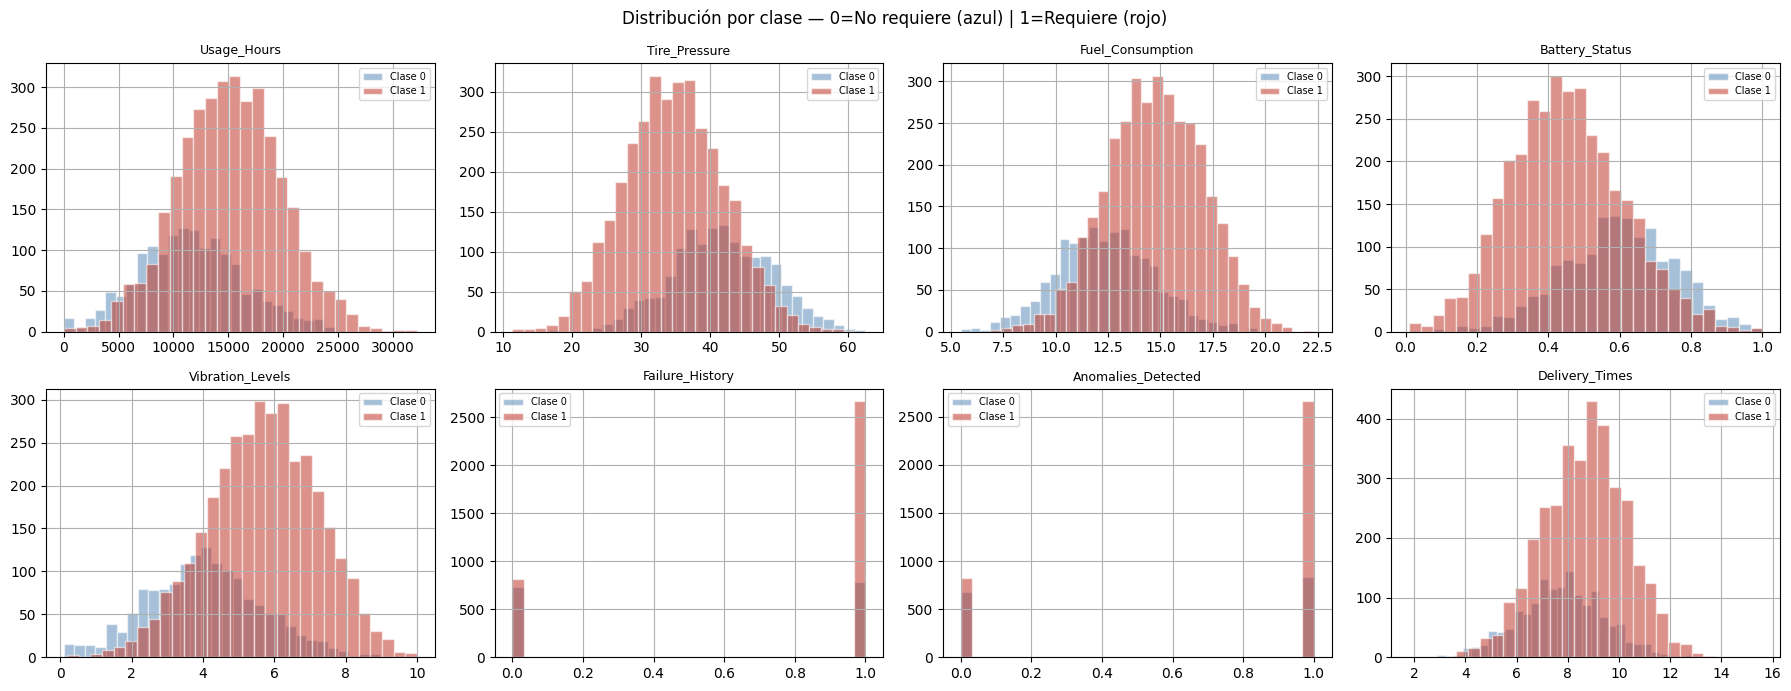

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(raw_num_feats[:8]):
    for cls, color in [(0, "#5B8DB8"), (1, "#C0392B")]:
        df[df["Maintenance_Required"] == cls][col].hist(
            ax=axes[i], bins=30, alpha=0.55, color=color,
            label=f"Clase {cls}", edgecolor="white"
        )
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)

plt.suptitle("Distribución por clase — 0=No requiere (azul) | 1=Requiere (rojo)",
             fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
# Verificar rangos de validación del config
assert df["Usage_Hours"].between(VAL["usage_hours_min"], VAL["usage_hours_max"]).all(), \
    "Usage_Hours fuera de rango"
assert df["Tire_Pressure"].between(VAL["tire_pressure_min"], VAL["tire_pressure_max"]).all(), \
    "Tire_Pressure fuera de rango"
assert df["Maintenance_Required"].isin([0, 1]).all(), \
    "Maintenance_Required contiene valores inesperados"
assert df.isnull().sum().sum() == 0, \
    "El dataset contiene nulos"

log.info("✓ Validaciones de rango y nulos OK")

2026-05-22 16:48:23 | INFO | ✓ Validaciones de rango y nulos OK


---
## 9. Guardar CSV

In [12]:
df.to_csv(OUTPUT_PATH, index=False)

log.info("✓ Dataset guardado en: %s", OUTPUT_PATH)
log.info("  Filas       : %d", len(df))
log.info("  Columnas    : %d", df.shape[1])
log.info("  Clase 1 (%%): %.1f%%", maintenance_required.mean() * 100)
log.info("  Siguiente   : ejecutar NB01 → NB02 → NB03 → NB04")

2026-05-22 16:48:28 | INFO | ✓ Dataset guardado en: ../data/raw/logistics_dataset_with_maintenance_required.csv


2026-05-22 16:48:28 | INFO |   Filas       : 5000


2026-05-22 16:48:28 | INFO |   Columnas    : 23


2026-05-22 16:48:28 | INFO |   Clase 1 (%): 69.6%


2026-05-22 16:48:28 | INFO |   Siguiente   : ejecutar NB01 → NB02 → NB03 → NB04
